# Practical Assingment

In [185]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from SALib.sample import saltelli
from SALib.analyze import sobol

### Basic model analysis

In [186]:
# Parameters and desicion variables
years = 30 # change to test how time affects
dt = 1 # annual step
annual_deposit = 3000  # $1,000 per fund
n_simulations = 10000
initial_val = 0

# Funds
funds_basic = {
    'Low_Risk': {'mu': 0.04, 'sigma': 0.02},
    'Med_Risk': {'mu': 0.07, 'sigma': 0.12},
    'High_Risk': {'mu': 0.10, 'sigma': 0.20}
}

funds_low = {
    'Low_Risk': {'mu': 0.04, 'sigma': 0.02}
}

funds_medium = {
    'Med_Risk': {'mu': 0.07, 'sigma': 0.12}
}

funds_high = {
    'High_Risk': {'mu': 0.10, 'sigma': 0.20}
}


In [187]:
def run_investment_sim(funds, is_random=True):
    """
    Simulates investment over time. 
    If is_random=True, it uses sigma (Monte Carlo).
    If is_random=False, it uses only mu (Average Case).
    """
    portfolio = {name: 0 for name in funds.keys()}
    history = [0]
    
    for year in range(1, years + 1):
        total_this_year = 0
        for name, params in funds.items():
            # External Uncertainty Toggle
            rate = np.random.normal(params['mu'], params['sigma']) if is_random else params['mu']
            
            # Stock Equation: New = (Old + Flow) * (1 + Rate)
            portfolio[name] = (portfolio[name] + (annual_deposit / len(funds))) * (1 + rate)
            total_this_year += portfolio[name]
        history.append(total_this_year)
    return history

In [188]:
# Generate the Average Case (Deterministic)
avg_output = run_investment_sim(funds=funds_basic, is_random=False)
avg_low = run_investment_sim(funds=funds_low, is_random=False)
avg_medium = run_investment_sim(funds=funds_medium, is_random=False)
avg_high = run_investment_sim(funds=funds_high, is_random=False)


In [189]:
# Monte Carlo for 10 000 cases in evenly divided deposit case
monte_carlo_paths = [run_investment_sim(funds=funds_basic, is_random=True) for _ in range(n_simulations)]

In [190]:
# Monte Carlo on 10 000 cases with only investing in one risk level fund

monte_carlo_low = [run_investment_sim(funds=funds_low, is_random=True) for _ in range(n_simulations)]
low_results = [monte_carlo_low[sim][-1] for sim in range(n_simulations)]
low_avg = np.mean(low_results)
low_min = np.min(low_results)
low_max = np.max(low_results)
print("Low risk fund performance")
print(f"Average case: {avg_low[-1]:,.2f}")
print(f"Avg: {low_avg:,.2f}")
print(f"Min: {low_min:,.2f}")
print(f"Max: {low_max:,.2f}\n")

monte_carlo_medium = [run_investment_sim(funds=funds_medium, is_random=True) for _ in range(n_simulations)]
medium_results = [monte_carlo_medium[sim][-1] for sim in range(n_simulations)]
medium_avg = np.mean(medium_results)
medium_min = np.min(medium_results)
medium_max = np.max(medium_results)
print("Medium risk fund performance")
print(f"Avg: {medium_avg:,.2f}")
print(f"Min: {medium_min:,.2f}")
print(f"Max: {medium_max:,.2f}\n")

monte_carlo_high = [run_investment_sim(funds=funds_high, is_random=True) for _ in range(n_simulations)]
high_results = [monte_carlo_high[sim][-1] for sim in range(n_simulations)]
high_avg = np.mean(high_results)
high_min = np.min(high_results)
high_max = np.max(high_results)
print("High risk fund performance")
print(f"Avg: {high_avg:,.2f}")
print(f"Min: {high_min:,.2f}")
print(f"Max: {high_max:,.2f}\n")

Low risk fund performance
Average case: 174,985.01
Avg: 175,076.40
Min: 134,624.37
Max: 228,897.36

Medium risk fund performance
Avg: 302,759.62
Min: 63,254.61
Max: 1,709,760.75

High risk fund performance
Avg: 548,449.12
Min: 19,670.93
Max: 9,783,143.40



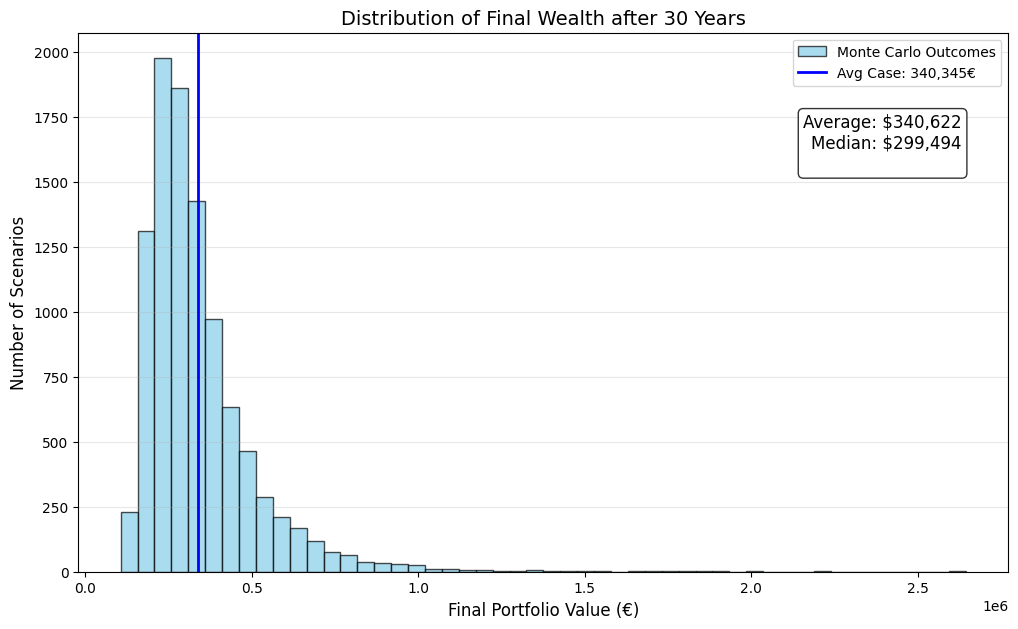

Final Value (Average Case): 340,344.80€
Min Value: 107,057.46€
Max Value: 2,644,979.67€


In [191]:
# Plotting
plt.figure(figsize=(12, 7))
final_values = [monte_carlo_paths[sim][-1] for sim in range(n_simulations)]

n, bins, patches = plt.hist(final_values, bins=50, color='skyblue', edgecolor='black', alpha=0.7, label='Monte Carlo Outcomes')

plt.axvline(avg_output[-1], color='blue', linestyle='-', linewidth=2, label=f'Avg Case: {avg_output[-1]:,.0f}€')

plt.title(f"Distribution of Final Wealth after {years} Years", fontsize=14)
plt.xlabel("Final Portfolio Value (€)", fontsize=12)
plt.ylabel("Number of Scenarios", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add a text box with statistics
stats_text = (f"Average: ${np.mean(final_values):,.0f}\n"
              f"Median: ${np.median(final_values):,.0f}\n")
plt.gca().text(0.95, 0.85, stats_text, transform=plt.gca().transAxes, 
               fontsize=12, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

print(f"Final Value (Average Case): {avg_output[-1]:,.2f}€")
print(f"Min Value: {np.min(final_values):,.2f}€")
print(f"Max Value: {np.max(final_values):,.2f}€")

In [200]:
# Monte Carlo simulation for SimDec
observations = []

for s in range(n_simulations):
    # Stocks for this specific simulation
    low_stock, med_stock, high_stock = 0, 0, 0
    
    # We will track the average return realized in this specific "life"
    realized_low, realized_med, realized_high = [], [], []
    
    for year in range(years):
        # Generate the random rates for this specific year
        r_low = np.random.normal(0.04, 0.02)
        r_med = np.random.normal(0.07, 0.12)
        r_high = np.random.normal(0.10, 0.20)
        
        # Track them
        realized_low.append(r_low)
        realized_med.append(r_med)
        realized_high.append(r_high)
        
        # Update Stocks (Deposit 1/3 in each)
        low_stock = (low_stock + annual_deposit/3) * (1 + r_low)
        med_stock = (med_stock + annual_deposit/3) * (1 + r_med)
        high_stock = (high_stock + annual_deposit/3) * (1 + r_high)
    
    total_wealth = low_stock + med_stock + high_stock
    
    # Save the observation
    observations.append({
        'Avg_Low_Rate': np.mean(realized_low),
        'Avg_Med_Rate': np.mean(realized_med),
        'Avg_High_Rate': np.mean(realized_high),
        'Final_Wealth': total_wealth
    })

# Create DataFrame
df_mc_data = pd.DataFrame(observations)

# Save to CSV
df_mc_data.to_csv('monte_carlo_results.csv', index=False)

print("Monte Carlo data captured!")
print(df_mc_data.head())


Monte Carlo data captured!
   Avg_Low_Rate  Avg_Med_Rate  Avg_High_Rate   Final_Wealth
0      0.040125      0.085970       0.105280  306421.451537
1      0.039518      0.111153       0.119958  434247.603936
2      0.032299      0.061094       0.057976  236294.348473
3      0.039885      0.011129       0.084979  232448.396399
4      0.044937      0.033784       0.145046  435126.541700


### Modeling uncertainty

In [192]:
# GBM
def simulate_multi_gbm(n_sims):
    # Dictionary to store the final year-30 values for each fund
    results = {name: [] for name in funds_basic}
    
    # We'll also store one sample realization (one "life") to show on a line chart
    sample_paths = {name: [0] for name in funds_basic}
    
    for _ in range(n_sims):
        portfolio = {name: 0 for name in funds_basic}
        for t in range(1, years + 1):
            for name, params in funds_basic.items():
                # GBM Step Equation
                Z = np.random.normal(0, 1)
                # Apply growth to current stock + add new deposit
                growth = np.exp((params['mu'] - 0.5 * params['sigma']**2) * dt + params['sigma'] * np.sqrt(dt) * Z)
                portfolio[name] = (portfolio[name] + annual_deposit/len(funds_basic)) * growth
                
                # Capture one sample path for the line chart
                if _ == 0:
                    sample_paths[name].append(portfolio[name])
                    
        for name in funds_basic:
            results[name].append(portfolio[name])
            
    return results, sample_paths

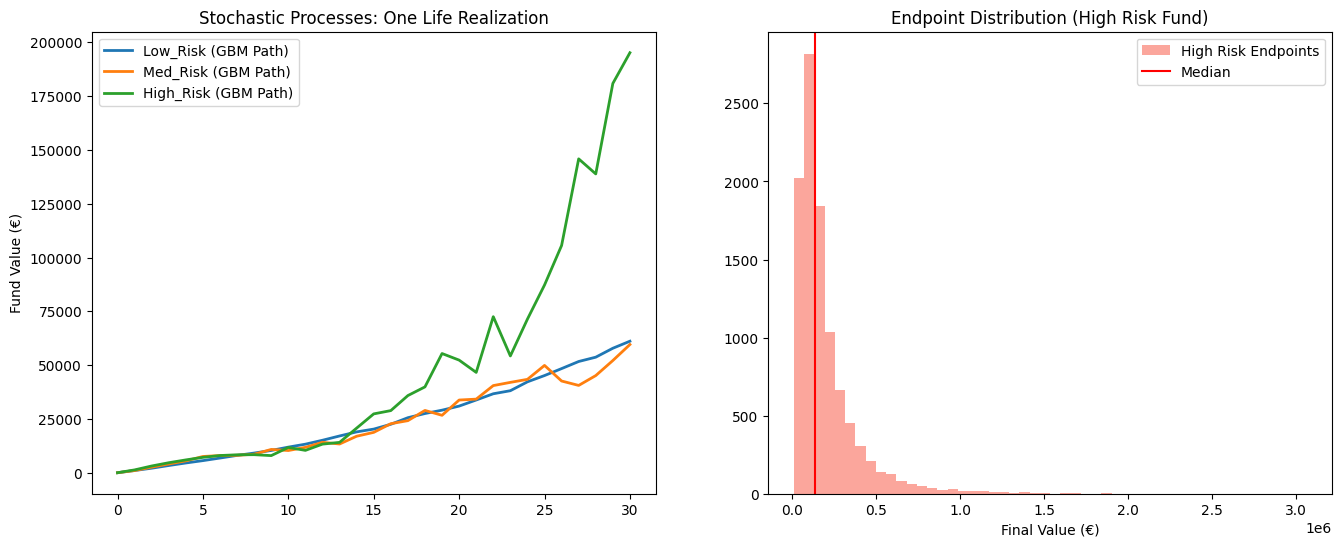

In [193]:
# Visualization
final_vals, sample_life = simulate_multi_gbm(n_simulations)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Realizations
for name in funds_basic:
    ax1.plot(sample_life[name], label=f"{name} (GBM Path)", linewidth=2)
ax1.set_title("Stochastic Processes: One Life Realization")
ax1.set_ylabel("Fund Value (€)")
ax1.legend()

# Histogram
ax2.hist(final_vals['High_Risk'], bins=50, color='salmon', alpha=0.7, label='High Risk Endpoints')
ax2.axvline(np.median(final_vals['High_Risk']), color='red', label='Median')
ax2.set_title("Endpoint Distribution (High Risk Fund)")
ax2.set_xlabel("Final Value (€)")
ax2.legend()

plt.show()

In [194]:
# Jump Parameters
lam = 0.1 # Prob of crash
jump_mu = -0.25 # Mean size of crash
jump_sigma = 0.1 # Variability of crash size

In [195]:
def simulate_jump_diffusion(funds, years, lam, j_mu, j_sigma, is_random=True):
    portfolio = {name: 0 for name in funds.keys()}
    history = [0]
    
    for year in range(1, years + 1):
        total_this_year = 0
        # Determining if crash happens
        if_jumps = np.random.poisson(lam * dt)
        # Calculating jump size if happens
        if if_jumps == 0:
            jumps = 1
        else: 
            jumps = np.exp(np.random.normal(j_mu, j_sigma))

        for name, params in funds.items():
            # External Uncertainty Toggle
            rate = np.random.normal(params['mu'], params['sigma']) if is_random else params['mu']
            
            # Stock Equation: New = (Old + Flow) * (1 + Rate)
            portfolio[name] = (portfolio[name] + (annual_deposit / len(funds))) * (1 + rate) * jumps
            total_this_year += portfolio[name]
        history.append(total_this_year)

    return history

In [196]:
# Run simulation
paths = [simulate_jump_diffusion(funds=funds_basic, years=years, lam=lam, j_mu=jump_mu, j_sigma=jump_sigma, is_random=True)for _ in range(n_simulations)]
#print(len(paths[-1]))
final_values = [paths[sim][-1] for sim in range(n_simulations)]

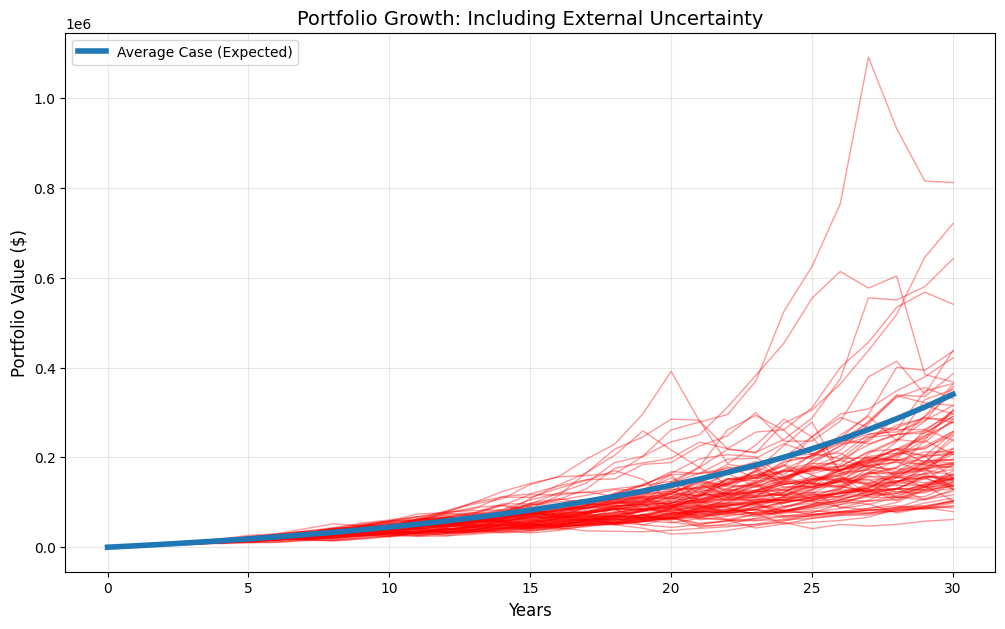

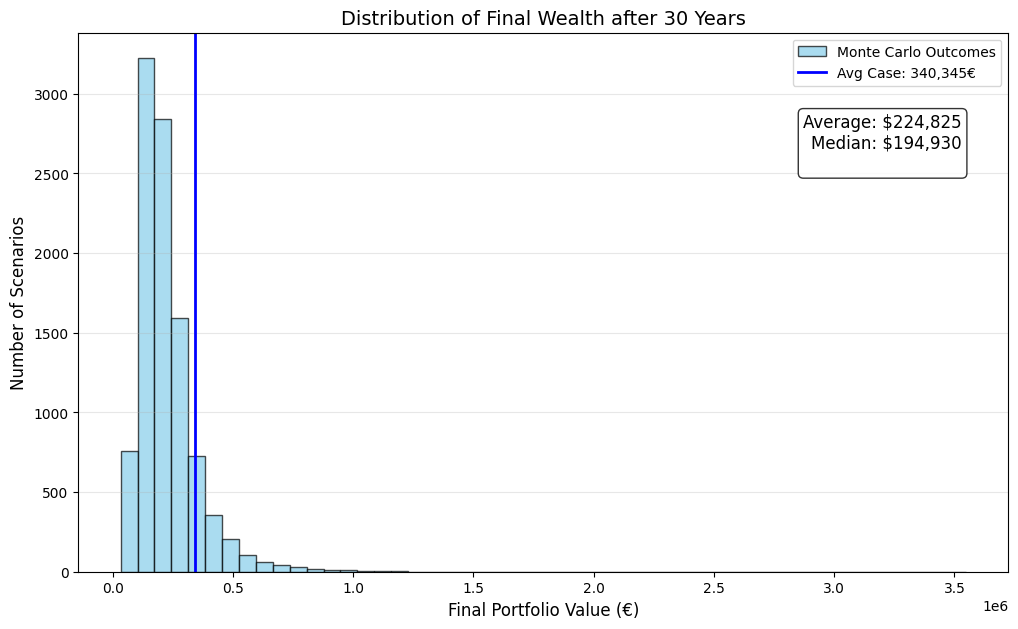

In [197]:
# Visualization
plt.figure(figsize=(12, 7))

# Plotting paths
for path in paths[1:100]:
    plt.plot(path, color='red', alpha=0.4, linewidth=1)
# Plot Average Case (Bold Blue)
plt.plot(avg_output, color='#1f77b4', linewidth=4, label='Average Case (Expected)')
plt.title("Portfolio Growth: Including External Uncertainty", fontsize=14)
plt.xlabel("Years", fontsize=12)
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Histogram
plt.figure(figsize=(12, 7))
n, bins, patches = plt.hist(final_values, bins=50, color='skyblue', edgecolor='black', alpha=0.7, label='Monte Carlo Outcomes')

plt.axvline(avg_output[-1], color='blue', linestyle='-', linewidth=2, label=f'Avg Case: {avg_output[-1]:,.0f}€')

plt.title(f"Distribution of Final Wealth after {years} Years", fontsize=14)
plt.xlabel("Final Portfolio Value (€)", fontsize=12)
plt.ylabel("Number of Scenarios", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add a text box with statistics
stats_text = (f"Average: ${np.mean(final_values):,.0f}\n"
              f"Median: ${np.median(final_values):,.0f}\n")
plt.gca().text(0.95, 0.85, stats_text, transform=plt.gca().transAxes, 
               fontsize=12, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

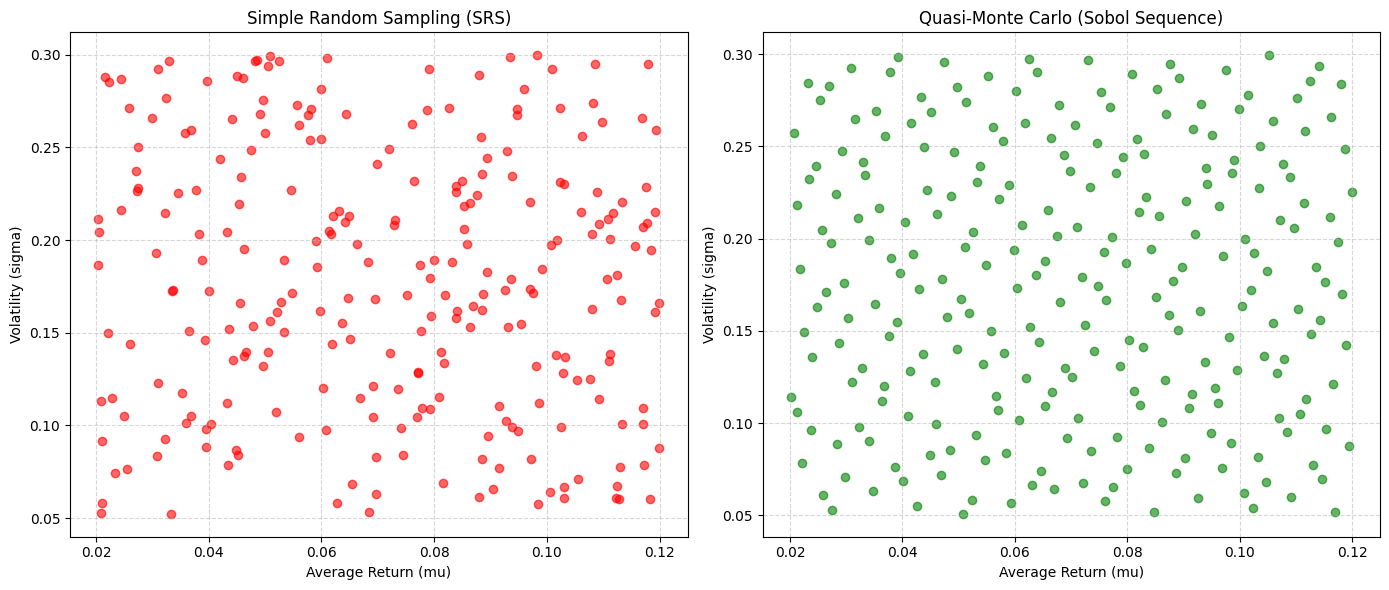

In [198]:
# Sampling

# Sampling setup
n_samples = 256 # powers of 2 for Sobol
l_bounds = [0.02, 0.05] # Min Return 2%, Min Volatility 5%
u_bounds = [0.12, 0.30] # Max Return 12%, Max Volatility 30%

# Sampling strategies
# Simple random sampling
srs_raw = np.random.rand(n_samples, 2)
srs_scaled = qmc.scale(srs_raw, l_bounds, u_bounds)

# Quasi-Monte Carlo (Sobol sequence)
sobol_engine = qmc.Sobol(d=2, scramble=True)
sobol_raw = sobol_engine.random(n=n_samples)
sobol_scaled = qmc.scale(sobol_raw, l_bounds, u_bounds)

# Visualizations
# Simple random
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.scatter(srs_scaled[:, 0], srs_scaled[:, 1], color='red', alpha=0.6, label='Random')
ax1.set_title("Simple Random Sampling (SRS)")
ax1.set_xlabel("Average Return (mu)")
ax1.set_ylabel("Volatility (sigma)")
ax1.grid(True, linestyle='--', alpha=0.5)

# Quasi-Monte Carlo
ax2.scatter(sobol_scaled[:, 0], sobol_scaled[:, 1], color='green', alpha=0.6, label='Sobol')
ax2.set_title("Quasi-Monte Carlo (Sobol Sequence)")
ax2.set_xlabel("Average Return (mu)")
ax2.set_ylabel("Volatility (sigma)")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

          First Order (S1)  Total Effect (ST)
Variable                                     
mu                0.802148           0.849942
sigma             0.147000           0.194286


C:\Users\hanna\AppData\Local\Temp\ipykernel_176116\2704522515.py:10: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 512)


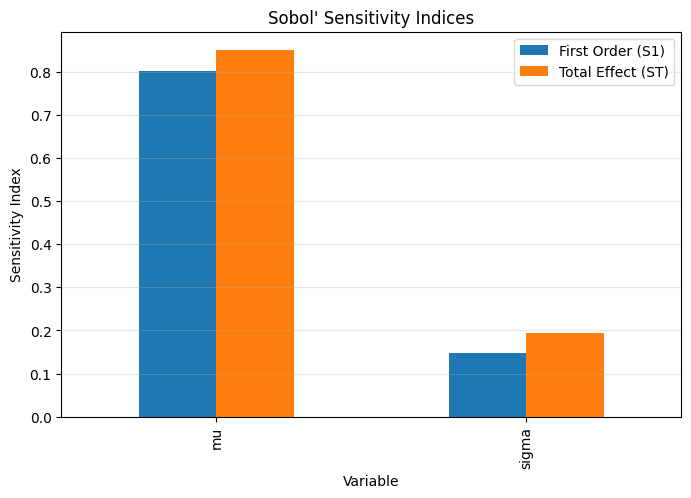

In [199]:
# Setup for SALib (Sobol Indices)
problem = {
    'num_vars': 2,
    'names': ['mu', 'sigma'],
    'bounds': [[0.02, 0.12], [0.05, 0.30]]
}

# Generate Samples
# Saltelli's method generates N * (2D + 2) samples
param_values = saltelli.sample(problem, 512)

# Model function
def evaluate_portfolio(params):
    mu, sigma = params
    years = 30
    annual_dep = 12000
    adj_mu = mu - 0.5 * (sigma**2)
    final_val = annual_dep * (((1 + adj_mu)**years - 1) / adj_mu)
    return final_val

# Running the model
outputs = np.array([evaluate_portfolio(p) for p in param_values])

# Perform analysis
Si = sobol.analyze(problem, outputs)

# Report results
results_df = pd.DataFrame({
    'Variable': problem['names'],
    'First Order (S1)': Si['S1'],
    'Total Effect (ST)': Si['ST']
}).set_index('Variable')

print(results_df)

# Visualization
results_df[['First Order (S1)', 'Total Effect (ST)']].plot(kind='bar', figsize=(8, 5))
plt.title("Sobol' Sensitivity Indices")
plt.ylabel("Sensitivity Index")
plt.grid(axis='y', alpha=0.3)
plt.show()